# Data Analysis and Topic Modeling of Hymns
## Project Advisor: Fernando Santos
## Project Team: Kailun(Daniel) Jin:
Calvin University Data Science Major, senior student.
##[Department of Computer Science](https://computing.calvin.edu/)
## [Project report](https://docs.google.com/document/d/16goQ9SurPOTJoYE1uIhox6Z9Pm5I_tQd/edit?usp=sharing&ouid=114915347334941835503&rtpof=true&sd=true)
## [Presentation PPT](https://calvincollege-my.sharepoint.com/:p:/g/personal/kj39_calvin_edu/IQBpdgF9eevFRKD1NGSBLQYCAZbEbpkG8jJ0rE5DFJsZWqg?e=VkGW6d)


# **Vision Statement:**

Hymns play a central role in Christian worship, serving as a powerful medium for praise, proclamation, and theological reflection. Yet, despite their importance, the thematic structure and linguistic patterns of hymns have rarely been examined through systematic, data-driven methods. Much of what we believe about hymn themes is based on tradition or intuition rather than empirical analysis. This project seeks to address that gap.

Using natural language processing (NLP), data cleaning techniques, and unsupervised topic modeling, we convert hymn texts into quantitative, analyzable data and uncover the major themes and frequently occurring words within a large corpus of hymns. Visualization tools such as pyLDAvis, word clouds, and statistical summaries enable us to present these patterns in a clear and interpretable way.

In addition to identifying core themes, our project also considers how hymn themes may shift across historical periods, allowing us to place linguistic patterns within their broader cultural and theological context. Through this approach, we aim to provide a deeper and more comprehensive understanding of the theological messages, worship practices, and historical development embedded in Christian hymnody.




# **Normative and Ethical Considerations:**

**Cultural Appropriateness:**
Technology must respect the cultural and religious background of 	hymns. Our analysis will not undermine or misinterpret the traditional and 	theological significance of the hymns, but rather aims to understand, 	preserve and present the thematic value within them.

**Transparency:**
We clearly explain the data processing methods, the principles and 	limitations of the LDA model, avoid exaggerating technical capabilities, and 	explain all charts and outputs in an easy-to-understand way.

**Social Consideration:**
Technology should promote positive interaction within the 	Christian community. Thematic analysis can help believers learn about the 	themes of the hymns together, strengthening the community's 	understanding and connection.
Designed the project to support learning and discussion, not to judge or rank hymns.

**Stewardship:**
Use resources reasonably and avoid waste.
Our system is lightweight, efficient and reusable, ensuring that data 	processing and visualization do not result in unnecessary consumption of 	computing resources.
Used lightweight, efficient tools and avoided energy-intensive models

**Aesthetics（Clear & Accessible Design）:**
The interface should be attractive, user-friendly and clear.
We chose tools such as pyLDAvis and word clouds not only because of their 	powerful functions, but also because they can provide an enjoyable and 	intuitive user experience.
Chose simple, intuitive visualizations and avoided cluttered or confusing 	charts.

**Justice:**
Avoid prejudice and respect copyright.
When using hymn texts, comply with copyright requirements, avoid creating 	misleading interpretations of theological themes, and prevent the model 	from generating unfair biases.
Followed copyright rules, checked for dataset bias, and avoided misleading 	results.

**Caring:**
Technology should promote neighborly love and spiritual growth.
The goal of this project is to help worshippers, students and researchers 	deeply understand the spiritual content of hymns, rather than replacing 	worship and faith-based life.

**Trust:**
The system should be reliable, secure, and in line with Christian 	values. We avoid inaccurate or misleading analyses so that users can trust 	the presented results, ensuring that technology does not distract people 	from their faith in God but rather assists in worship and learning.


**Background**

Helpful backgorund study resources about LDA Modeling:

	URL: https://investigate.ai/text-analysis/topic-models-with-gensim/ (investigate.ai)

Author: Jonathan Soma, who runs/ran the Lede Program at Columbia Journalism School and created these materials for teaching data journalism. (investigate.ai)

**Data Source:**

Hymnary.org( An organization that collect hymns)

Meeting with Mr. Groenendyk (Will Groenendyk), woker of Hymmary Orgnization, and get data of hymns from him in the form of xlsx.


# Code Part

# **Data**

In [1]:
# Library Importing
import pandas as pd
import numpy as np
import random
random.seed(42)
# warning set
import warnings
warnings.filterwarnings("ignore", message=".*utcnow.*", category=DeprecationWarning)

**Data cleaning and organization**



In [2]:
# Load whole excel file name as All
All = pd.read_excel("https://docs.google.com/spreadsheets/d/1gGFhkPx9-nkUC5xZIdNm2p0SsBjeb5Rv/export?format=xlsx", sheet_name= None)

In [3]:
# Take out the Hymns sheet which contain all text of hymns and delete empty columns
Hymns = All["Hymns"]
Hymns = Hymns.iloc[:, :9]
print(len(Hymns)) # get the total rows number of data
print(Hymns.duplicated().sum()) # check if there are duplicated rows
Hymns.head()

96999
0


,Hymn ID,Title,First Line,Refrain First Line,Text,Authority Number,Publication Year,Hymn Number,Hymnal ID
0,2321898,A call to the spiritual warfare,"Christ's trumpet sounds, let saints be arm'd",NaN,"1 Christ's trumpet sounds, let saints be arm'd...",christs_trumpet_sounds_let_saints_be_arm,1782,III,ACCH1782
1,2321899,Christians excited to obedience by beholding a...,"Come all ye Christians, view",NaN,1 Come all ye Christians view\nThese soldiers ...,come_all_ye_christians_view,1782,IV,ACCH1782
2,2321907,An exhortation to prayer,"Come, let us join for to adore",NaN,"1 Come, let us join for to ador\nThe sacred on...",come_let_us_join_for_to_adore,1782,XII,ACCH1782
3,2321896,America's future glory and happiness,"Come rise, my soul, to noble things",NaN,"1 Come rise, my soul, to noble things,\nAnd tr...",come_rise_my_soul_to_noble_things,1782,I,ACCH1782
4,2321908,"To be with Christ, for me is far better",If all the globe belong'd to me,NaN,"1 If all the globe belong'd to me,\nBoth lands...",if_all_the_globe_belonged_to_me,1782,XIII,ACCH1782


In [4]:
Hymns =  Hymns.rename(
    columns={
        "Hymn ID" : "Hymn_ID",
        "First Line": "First_Line",
        "Refrain First Line": "Refrain_First_Line",
        "Authority Number": "Authority_Number",
        "Publication Year": "Publication_Year",
        "Hymn Number": "Hymn_Number",
        "Hymnal ID": "Hymnal_ID"
    }
)

In [5]:
# Take out the Languages sheet which record the language type of each hymns
Language = All["Hymns - Languages"]
print(len(Language))
print(Language.duplicated().sum())
Language.head()

87248
0


,Hymn ID,Language
0,2321898,English
1,2321899,English
2,2321907,English
3,2321896,English
4,2321908,English


In [6]:
Language = Language.rename(
    columns={
        "Hymn ID" : "Hymn_ID"
    }
)

In [7]:
# Inner Join the Hymns sheet, Languages sheet and Denominzations sheet
New_Hymns = pd.merge(Hymns, Language, on="Hymn_ID", how= "inner")
print(len(New_Hymns))
New_Hymns.head()

87156


,Hymn_ID,Title,First_Line,Refrain_First_Line,Text,Authority_Number,Publication_Year,Hymn_Number,Hymnal_ID,Language
0,2321898,A call to the spiritual warfare,"Christ's trumpet sounds, let saints be arm'd",NaN,"1 Christ's trumpet sounds, let saints be arm'd...",christs_trumpet_sounds_let_saints_be_arm,1782,III,ACCH1782,English
1,2321899,Christians excited to obedience by beholding a...,"Come all ye Christians, view",NaN,1 Come all ye Christians view\nThese soldiers ...,come_all_ye_christians_view,1782,IV,ACCH1782,English
2,2321907,An exhortation to prayer,"Come, let us join for to adore",NaN,"1 Come, let us join for to ador\nThe sacred on...",come_let_us_join_for_to_adore,1782,XII,ACCH1782,English
3,2321896,America's future glory and happiness,"Come rise, my soul, to noble things",NaN,"1 Come rise, my soul, to noble things,\nAnd tr...",come_rise_my_soul_to_noble_things,1782,I,ACCH1782,English
4,2321908,"To be with Christ, for me is far better",If all the globe belong'd to me,NaN,"1 If all the globe belong'd to me,\nBoth lands...",if_all_the_globe_belonged_to_me,1782,XIII,ACCH1782,English


In [8]:
# Filter the language only keep English
English = New_Hymns[New_Hymns["Language"] == "English"]
English = English.reset_index(drop=True)
print(len(English))
English.count()

76378


,0
Hymn_ID,76378
Title,54304
First_Line,76378
Refrain_First_Line,15241
Text,76378
Authority_Number,76376
Publication_Year,76375
Hymn_Number,76377
Hymnal_ID,76371
Language,76378




---

From the above table, we can see that some columns contain missing data. However, the data we mainly use will be:

Text: The main text of hymn

Publication Year: The year of hymn release,

The other columns will not be used, because it is uesd to identified the three factors above.

In [9]:
English = English[["Hymn_ID", "Text","Publication_Year"]]
English = English.dropna() # because there are some null value in the Pulication Year columns.
English.count()

,0
Hymn_ID,76375
Text,76375
Publication_Year,76375


In [10]:
#Check the number of hymns for each year and determine their time frame, then clean the data
English["Publication_Year"] = pd.to_numeric(English["Publication_Year"], errors= 'coerce')

In [11]:
English["Publication_Year"].value_counts().sort_index()

,count
Publication_Year,
17.0,1
117.0,1
285.0,1
1650.0,2
1737.0,78
...,...
2020.0,15
2021.0,1123
2022.0,734


There are still some years that record in wrong way, we cannot sure what it should be, and we will focuse on the hymn before 1600. So we will make a filter for it.

In [12]:
English = English[
    (English["Publication_Year"] >= 1600) &
    (English["Publication_Year"] <= 2024)
].copy()
English["Publication_Year"] = English["Publication_Year"].astype(int)

In [13]:
English["Publication_Year"].value_counts().sort_index()

,count
Publication_Year,
1650,2
1737,78
1752,193
1756,148
1758,247
...,...
2020,15
2021,1123
2022,734


In [14]:
English.count()

,0
Hymn_ID,76349
Text,76349
Publication_Year,76349


Above table shows that the publication years of hymns range from 1650 to 2024.
We decide to split it to four period.


In [15]:
bins = [1600, 1800, 1900,1990, 2026]
labels = [
    "1600-1800 Early/Revival roots",
    "1800-1899 19th-century hymnody",
    "1900-1989 Modern hymnals & early contemporary",
    "1990-2024 Contemporary worship & digital/global"
]
English["HistoricalPeriod"] = pd.cut(English["Publication_Year"], bins=bins, labels=labels, right=False)

In [16]:
English["HistoricalPeriod"].value_counts().sort_index()


,count
HistoricalPeriod,
1600-1800 Early/Revival roots,5905
1800-1899 19th-century hymnody,10564
1900-1989 Modern hymnals & early contemporary,23923
1990-2024 Contemporary worship & digital/global,35957


In [17]:
English.head()

,Hymn_ID,Text,Publication_Year,HistoricalPeriod
0,2321898,"1 Christ's trumpet sounds, let saints be arm'd...",1782,1600-1800 Early/Revival roots
1,2321899,1 Come all ye Christians view\nThese soldiers ...,1782,1600-1800 Early/Revival roots
2,2321907,"1 Come, let us join for to ador\nThe sacred on...",1782,1600-1800 Early/Revival roots
3,2321896,"1 Come rise, my soul, to noble things,\nAnd tr...",1782,1600-1800 Early/Revival roots
4,2321908,"1 If all the globe belong'd to me,\nBoth lands...",1782,1600-1800 Early/Revival roots


In [18]:
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # remove HTML label
    text = re.sub(r"<[^>]+>", " ", text)

    # when encounter SPANISH delete what behind
    text = re.split(r'(?mi)^\s*SPANISH\b.*$', text, maxsplit=1)[0]

    return text.strip()

In [19]:
English["Text"] = English["Text"].apply(clean_text)

In [20]:
English = English.sort_values(["Hymn_ID"], kind="mergesort").reset_index(drop=True)

# **Model Output**

**Building LDA Modeling**


In [21]:
!pip install gensim==4.4.0 # install gensim library, a library that include LDA model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.7 MB/s eta 0:00:00


In [22]:
from gensim.parsing.preprocessing import STOPWORDS
extra_stop = {
    "thou", "thee", "thy", "thine", "ye","que", "señor", "estribillo","que", "señor", "estribillo", "und"
}
all_stop = STOPWORDS.union(extra_stop)

In [23]:
from gensim.utils import simple_preprocess

English["tokens"] = English["Text"].fillna("").apply(
    lambda s: [w for w in simple_preprocess(s, min_len=3) if w not in all_stop]
)

In [24]:
English["tokens"]

,tokens
0,"[glorious, heavenly, king, reigns, sky, shall,..."
1,"[sing, almighty, power, god, mountains, rise, ..."
2,"[blest, wisdom, power, justice, grace, join, c..."
3,"[whene, walks, abroad, poor, shall, render, go..."
4,"[great, god, voice, raise, youngest, hours, be..."
...,...
76344,"[jesu, jesu, fair, art, holy, pure, raiment, p..."
76345,"[friends, said, master, sharing, kingly, grace..."
76346,"[heard, glad, news, gospel, makes, happy, free..."
76347,"[promises, god, book, divine, meet, circumstan..."


In [25]:
from gensim.models.phrases import Phrases, Phraser
phrases = Phrases(English["tokens"].tolist(), min_count=12, threshold=25)
bigram = Phraser(phrases)
English["tokens_bigram"] = [bigram[t] for t in English["tokens"].tolist()]


In [26]:
sum_bigram = 0
sum_token = 0

for doc in English["tokens_bigram"]:
    sum_token += len(doc)
    sum_bigram += sum(1 for w in doc if "_" in w)

print("Total_number :", sum_token)
print("bigram_number:", sum_bigram)
print("bigram_percentage:", sum_bigram / sum_token)

Total_number : 4565576
bigram_number: 245383
bigram_percentage: 0.05374634000178729


In [27]:
from collections import Counter

counter = Counter()
for doc in English["tokens_bigram"]:
    counter.update([w for w in doc if "_" in w])

for bg, cnt in counter.most_common(50):
    print(bg, cnt)

heav_nly 4379
holy_ghost 2294
set_free 2137
right_hand 1847
king_kings 1206
sov_reign 926
hosanna_highest 919
age_age 898
draw_near 889
hallelujah_hallelujah 864
good_news 715
kyrie_eleison 654
tell_story 653
sun_moon 620
wand_ring 586
dwelling_place 567
loving_kindness 555
open_wide 521
rock_ages 489
suff_ring 466
loved_ones 437
bread_wine 433
east_west 410
blessings_flow 402
glad_tidings 396
eat_bread 393
run_race 391
wond_rous 390
sons_daughters 389
narrow_way 389
rising_sun 354
lamb_slain 344
long_ago 339
sins_forgiven 338
list_ning 337
lift_heads 332
ages_past 323
ancient_days 317
draw_nigh 315
cov_nant 314
hosanna_hosanna 312
ride_ride 309
drink_cup 307
sinners_slain 298
pard_ning 298
newborn_king 295
thousand_thousand 293
rod_staff 275
long_expected 271
virgin_mother 266


In [28]:
from gensim import corpora

dictionary = corpora.Dictionary(English["tokens_bigram"])
dictionary.filter_extremes(no_below=10, no_above=0.7, keep_n=20000)
corpus = [dictionary.doc2bow(text) for text in English["tokens_bigram"]]

In [29]:
from gensim import models

lda = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    passes=10,
    random_state=42
)

In [30]:
for i in range(lda.num_topics):
    print(f"\nTopic {i}")
    print([w for w, p in lda.show_topic(i, topn=15)])


Topic 0
['love', 'god', 'life', 'christ', 'know', 'world', 'way', 'follow', 'peace', 'live', 'spirit', 'living', 'lord', 'walk', 'hope']

Topic 1
['shall', 'soul', 'day', 'god', 'lord', 'heart', 'life', 'way', 'jesus', 'rest', 'love', 'till', 'hand', 'let', 'trust']

Topic 2
['jesus', 'come', 'chorus', 'lord', 'home', 'let', 'love', 'blessed', 'bread', 'heart', 'yes', 'coming', 'tell', 'want', 'hear']

Topic 3
['lord', 'holy', 'love', 'spirit', 'let', 'heart', 'grace', 'word', 'pray', 'hear', 'come', 'god', 'hearts', 'faith', 'light']

Topic 4
['lord', 'god', 'shall', 'let', 'praise', 'great', 'earth', 'people', 'good', 'bless', 'mercy', 'word', 'land', 'hand', 'like']

Topic 5
['shall', 'light', 'day', 'glory', 'earth', 'sing', 'bright', 'night', 'song', 'sun', 'heaven', 'land', 'hallelujah', 'angels', 'happy']

Topic 6
['praise', 'alleluia', 'god', 'lord', 'sing', 'glory', 'king', 'let', 'earth', 'amen', 'holy', 'father', 'song', 'son', 'crown']

Topic 7
['shall', 'stand', 'tis', 'g

In [31]:
doc_topics = [lda.get_document_topics(bow) for bow in corpus]

English["topic_distribution"] = doc_topics
English["dominant_topic"] = [
    max(topics, key=lambda x: x[1])[0] if topics else None
    for topics in doc_topics
]
English["dominant_topic_prob"] = [
    max(topics, key=lambda x: x[1])[1] if topics else None
    for topics in doc_topics
]
English.head()


,Hymn_ID,Text,Publication_Year,HistoricalPeriod,tokens,tokens_bigram,topic_distribution,dominant_topic,dominant_topic_prob
0,52459,"How glorious is our heavenly King, \n Who reig...",1866,1800-1899 19th-century hymnody,"[glorious, heavenly, king, reigns, sky, shall,...","[glorious, heavenly, king, reigns, sky, shall,...","[(2, 0.062146), (4, 0.2096006), (5, 0.13542944...",6,0.375635
1,52460,"I sing th&#8217; almighty power of God, \n Tha...",1866,1800-1899 19th-century hymnody,"[sing, almighty, power, god, mountains, rise, ...","[sing, almighty, power, god, mountains, rise, ...","[(4, 0.58369094), (5, 0.1763994), (7, 0.2310424)]",4,0.583691
2,52461,"Blest be the wisdom and the power, \n The just...",1866,1800-1899 19th-century hymnody,"[blest, wisdom, power, justice, grace, join, c...","[blest, wisdom, power, justice, grace, join, c...","[(0, 0.01285989), (1, 0.026429545), (3, 0.0603...",7,0.435197
3,52462,"Whene&#8217;er I take my walks abroad, \n How ...",1866,1800-1899 19th-century hymnody,"[whene, walks, abroad, poor, shall, render, go...","[whene, walks, abroad, poor, shall, render, go...","[(0, 0.08497761), (1, 0.1634036), (2, 0.132255...",7,0.293352
4,52463,"Great God, to thee my voice I raise, \n To the...",1866,1800-1899 19th-century hymnody,"[great, god, voice, raise, youngest, hours, be...","[great, god, voice, raise, youngest, hours, be...","[(1, 0.14989866), (3, 0.10546874), (4, 0.25088...",7,0.337626


In [32]:
# Through each topic words, we named each topics
topic_labels = {
    0: "Christian life and discipleship",
    1: "Rest, trust, and the soul",
    2: "Invitation and communion",
    3: "Prayer, grace, and the Spirit",
    4: "Praise and blessing",
    5: "Light, glory, and heaven",
    6: "Doxology and royal praise",
    7: "Cross, sin, and redemption",
    8: "Atonement and salvation",
    9: "Life of Christ: birth and resurrection"
}

English["dominant_topic_label"] = English["dominant_topic"].map(topic_labels)

In [33]:
# shortcut for topic for plot
short_topic_labels = {
    "Christian life and discipleship": "Christian life",
    "Rest, trust, and the soul": "Rest/trust",
    "Invitation and communion": "Invitation",
    "Prayer, grace, and the Spirit": "Prayer/Spirit",
    "Praise and blessing": "Praise",
    "Light, glory, and heaven": "Light/glory",
    "Doxology and royal praise": "Doxology",
    "Cross, sin, and redemption": "Cross/redemption",
    "Atonement and salvation": "Atonement",
    "Life of Christ: birth and resurrection": "Christ life"
}
English["dominant_topic_short"] = English["dominant_topic_label"].map(short_topic_labels)

In [34]:
# shortcut for period
period_short_labels = {
    "1600-1800 Early/Revival roots": "1600-1800",
    "1800-1899 19th-century hymnody": "1800-1899",
    "1900-1989 Modern hymnals & early contemporary": "1900-1989",
    "1990-2024 Contemporary worship & digital/global": "1990-2024"
}
English["HistoricalPeriod_short"] = English["HistoricalPeriod"].map(period_short_labels)

In [35]:
English.head()

,Hymn_ID,Text,Publication_Year,HistoricalPeriod,tokens,tokens_bigram,topic_distribution,dominant_topic,dominant_topic_prob,dominant_topic_label,dominant_topic_short,HistoricalPeriod_short
0,52459,"How glorious is our heavenly King, \n Who reig...",1866,1800-1899 19th-century hymnody,"[glorious, heavenly, king, reigns, sky, shall,...","[glorious, heavenly, king, reigns, sky, shall,...","[(2, 0.062146), (4, 0.2096006), (5, 0.13542944...",6,0.375635,Doxology and royal praise,Doxology,1800-1899
1,52460,"I sing th&#8217; almighty power of God, \n Tha...",1866,1800-1899 19th-century hymnody,"[sing, almighty, power, god, mountains, rise, ...","[sing, almighty, power, god, mountains, rise, ...","[(4, 0.58369094), (5, 0.1763994), (7, 0.2310424)]",4,0.583691,Praise and blessing,Praise,1800-1899
2,52461,"Blest be the wisdom and the power, \n The just...",1866,1800-1899 19th-century hymnody,"[blest, wisdom, power, justice, grace, join, c...","[blest, wisdom, power, justice, grace, join, c...","[(0, 0.01285989), (1, 0.026429545), (3, 0.0603...",7,0.435197,"Cross, sin, and redemption",Cross/redemption,1800-1899
3,52462,"Whene&#8217;er I take my walks abroad, \n How ...",1866,1800-1899 19th-century hymnody,"[whene, walks, abroad, poor, shall, render, go...","[whene, walks, abroad, poor, shall, render, go...","[(0, 0.08497761), (1, 0.1634036), (2, 0.132255...",7,0.293352,"Cross, sin, and redemption",Cross/redemption,1800-1899
4,52463,"Great God, to thee my voice I raise, \n To the...",1866,1800-1899 19th-century hymnody,"[great, god, voice, raise, youngest, hours, be...","[great, god, voice, raise, youngest, hours, be...","[(1, 0.14989866), (3, 0.10546874), (4, 0.25088...",7,0.337626,"Cross, sin, and redemption",Cross/redemption,1800-1899


/tmp/ipykernel_777/4242750778.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  English.groupby(["HistoricalPeriod_short", "dominant_topic_short"])


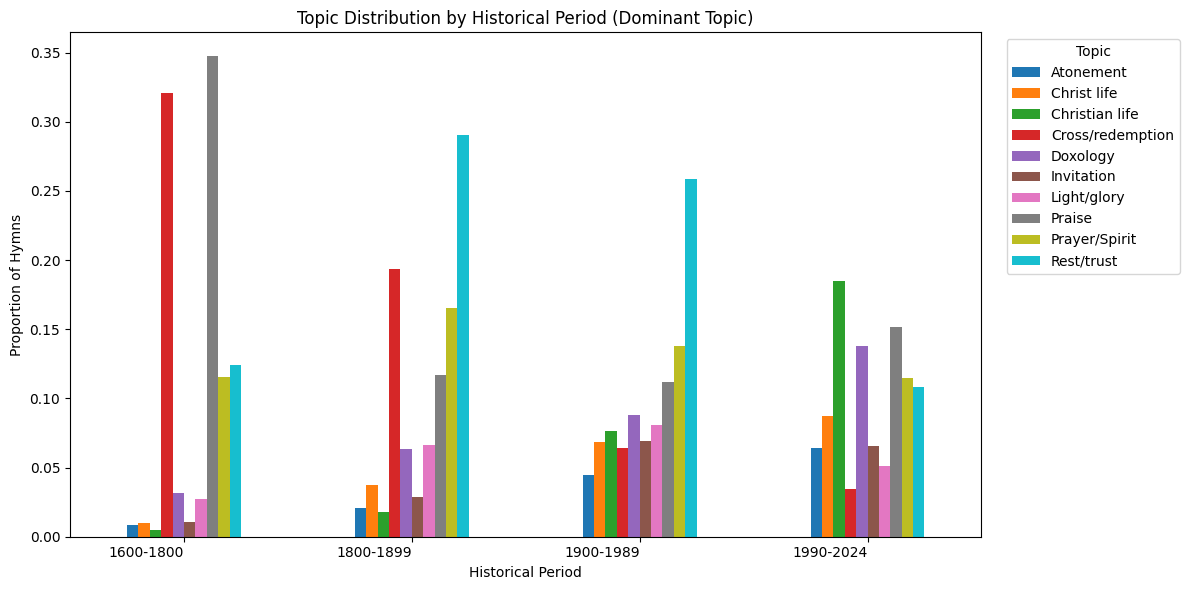

In [36]:
# making plot to show the result
import matplotlib.pyplot as plt
topic_counts = (
    English.groupby(["HistoricalPeriod_short", "dominant_topic_short"])
    .size()
    .unstack(fill_value=0)
)


# Obtain the proportion of each topic in each period
topic_props = topic_counts.div(topic_counts.sum(axis=1), axis=0)

# plotting
ax = topic_props.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6)
)

ax.set_title("Topic Distribution by Historical Period (Dominant Topic)")
ax.set_xlabel("Historical Period")
ax.set_ylabel("Proportion of Hymns")
plt.xticks(rotation=0, ha="right")
plt.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [37]:
 !pip install pyLDAvis==3.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 8.3 MB/s eta 0:00:00


In [39]:
# Shows the model output
import pyLDAvis
import pyLDAvis.gensim_models

vis = pyLDAvis.gensim_models.prepare(lda, corpus, dictionary, sort_topics=False)
pyLDAvis.display(vis)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Result Conslusion

Based on the above plot we made, we have reached the following conclusion:

1600–1800

Early hymns are mainly shaped by Praise and Cross/Redemption.This suggests a strong focus on worship, salvation, and theological devotion.

1800–1899

The dominant theme shifts to Rest/Trust, while Cross/Redemption and Prayer/Spirit remain important.This reflects greater emphasis on personal comfort, trust, and inward faith.

1900–1989

Rest/Trust remains strong, but the distribution becomes more balanced across topics such as Prayer/Spirit, Praise, and Doxology.This suggests increasing thematic diversity in hymn writing.

1990–2024

Christian Life becomes the most prominent theme.Contemporary hymns place more emphasis on discipleship, personal faith experience, and practical spiritual living.